# Etapa 1. Preprocesamiento y detección de *data leakage*
Dataset *Heart Failure Prediction* (918 pacientes, 11 variables, objetivo `HeartDisease`).
Semilla 42, partición 80/20 estratificada.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from src.common import *
raw = pd.read_csv(ROOT / "data" / "heart.csv")
print(raw.shape); raw.head()

(918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1. Exploración y valores faltantes

In [2]:
print(raw[TARGET].value_counts(normalize=True).round(3))
print("Colesterol = 0:", (raw.Cholesterol == 0).sum(), "| PA reposo = 0:", (raw.RestingBP == 0).sum())
raw.describe().T.round(2)

HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64
Colesterol = 0: 172 | PA reposo = 0: 1


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.51,9.43,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.40,18.51,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.80,109.38,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.23,0.42,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.81,25.46,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.89,1.07,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.55,0.50,0.0,0.00,1.0,1.0,1.0


**Interpretación.** La clase positiva es el 55,3 %, así que el problema está casi balanceado y accuracy
es una métrica razonable junto al AUC. Hay 172 pacientes con colesterol 0 y uno con presión 0: valores
fisiológicamente imposibles que codifican datos ausentes. Se convierten en `NaN` y se imputan con la
mediana **dentro del pipeline** (solo con datos de entrenamiento).

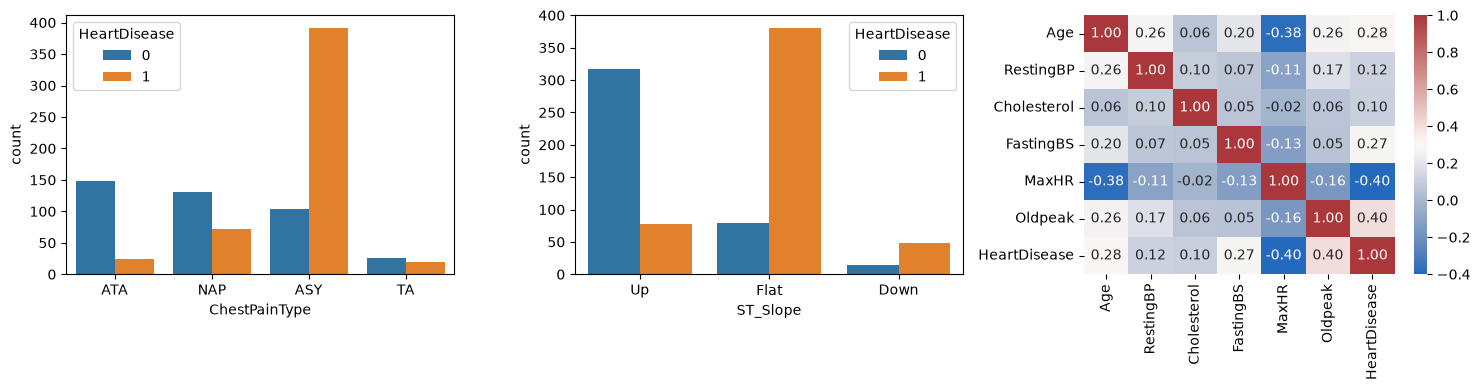

In [3]:
df = load_data()
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="ChestPainType", hue=TARGET, ax=ax[0])
sns.countplot(data=df, x="ST_Slope", hue=TARGET, ax=ax[1])
sns.heatmap(df[NUM + [TARGET]].corr(), annot=True, fmt=".2f", cmap="vlag", ax=ax[2])
plt.tight_layout(); plt.show()

**Interpretación.** La angina asintomática (`ASY`) y la pendiente plana/descendente del segmento ST se
asocian con la enfermedad; entre las numéricas, `Oldpeak` correlaciona positivamente y `MaxHR`
negativamente con el objetivo. Son las señales que los modelos deberían recuperar.

## 2. Demostración de fuga de datos
Se añade una variable artificial `leaky_feature = y + ruido`. Se compara (a) escalar con todo el
conjunto antes de partir y dejar la fuga activa frente a (b) el flujo correcto con `Pipeline`.
Para aislar los dos tipos de fuga se evalúan tres escenarios.

In [4]:
Xd = pd.get_dummies(df.drop(columns=TARGET), drop_first=False).astype(float)
Xd = Xd.fillna(Xd.median()); y = df[TARGET]
rng = np.random.default_rng(0)
leaky = y + rng.normal(0, 0.01, len(y))
grid_p = {"C": [0.1, 1, 10], "gamma": [0.01, 0.1]}

def run_leaky(X):
    Xs = MinMaxScaler().fit_transform(X)                       # escalado con TODO el conjunto
    a, b, c, d = train_test_split(Xs, y, test_size=0.2, stratify=y, random_state=SEED)
    g = GridSearchCV(SVC(probability=True, random_state=SEED), grid_p, cv=5, scoring="roc_auc").fit(a, c)
    return roc_auc_score(d, g.predict_proba(b)[:, 1])

def run_clean(X):
    a, b, c, d = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    p = Pipeline([("sc", MinMaxScaler()), ("svc", SVC(probability=True, random_state=SEED))])
    g = GridSearchCV(p, {"svc__C": grid_p["C"], "svc__gamma": grid_p["gamma"]}, cv=5, scoring="roc_auc").fit(a, c)
    return roc_auc_score(d, g.predict_proba(b)[:, 1])

X_leak = Xd.assign(leaky_feature=leaky)
res = pd.Series({
    "Con variable fuga + escalado global": run_leaky(X_leak),
    "Con variable fuga + Pipeline": run_clean(X_leak),
    "Sin variable fuga + escalado global": run_leaky(Xd),
    "Sin variable fuga + Pipeline (correcto)": run_clean(Xd)}).round(4)
res

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

Con variable fuga + escalado global        1.0000
Con variable fuga + Pipeline               1.0000
Sin variable fuga + escalado global        0.9280
Sin variable fuga + Pipeline (correcto)    0.9283
dtype: float64

**Interpretación.** La variable artificial lleva el AUC prácticamente a 1, y eso ocurre aunque se use
`Pipeline`: la fuga por una variable que contiene la respuesta no la corrige ninguna técnica de
validación, solo la revisión de las variables (una AUC casi perfecta en datos clínicos reales es señal
de alarma). El escalado global, en cambio, es una fuga sutil: la diferencia entre las filas
"escalado global" y "Pipeline" sin variable fuga es pequeña, porque MinMax filtra solo mínimos y
máximos, pero el procedimiento correcto es el único que garantiza que la estimación de prueba sea
honesta.

## 3. Comparación de modelos sin fuga (Pipeline + GridSearchCV)

In [5]:
X_train, X_test, y_train, y_test = split(df)
modelos = {
    "SVC": (SVC(probability=True, random_state=SEED), {"clf__C": [0.1, 1, 10], "clf__gamma": [0.01, 0.1, "scale"]}),
    "LogisticRegression": (LogisticRegression(max_iter=2000), {"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "RandomForest": (RandomForestClassifier(random_state=SEED), {"clf__n_estimators": [200, 500], "clf__max_depth": [3, 5, None], "clf__min_samples_leaf": [1, 3, 5]}),
    "KNN": (KNeighborsClassifier(), {"clf__n_neighbors": [3, 5, 9, 15, 25], "clf__weights": ["uniform", "distance"]}),
    "GradientBoosting": (GradientBoostingClassifier(random_state=SEED), {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.03, 0.1], "clf__max_depth": [2, 3]}),
}
filas, ajustados = [], {}
for nombre, (m, pg) in modelos.items():
    g = train_pipeline(X_train, y_train, m, pg)
    p = g.predict_proba(X_test)[:, 1]
    ajustados[nombre] = g
    filas.append({"modelo": nombre, "AUC_cv": g.best_score_, "AUC_test": roc_auc_score(y_test, p),
                  "Accuracy_test": accuracy_score(y_test, p > .5), "mejores_params": g.best_params_})
ranking = pd.DataFrame(filas).sort_values("AUC_test", ascending=False).reset_index(drop=True)
ranking.index += 1
ranking.round(4)

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/cjmolina/.venvs/heart-mlops/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

,modelo,AUC_cv,AUC_test,Accuracy_test,mejores_params
1,KNN,0.9130,0.9349,0.8859,"{'clf__n_neighbors': 25, 'clf__weights': 'dist..."
2,LogisticRegression,0.9227,0.9309,0.8967,{'clf__C': 1}
3,GradientBoosting,0.9269,0.9289,0.8967,"{'clf__learning_rate': 0.03, 'clf__max_depth':..."
4,RandomForest,0.9315,0.9275,0.8804,"{'clf__max_depth': 5, 'clf__min_samples_leaf':..."
5,SVC,0.9194,0.9143,0.8315,"{'clf__C': 0.1, 'clf__gamma': 0.1}"


**Interpretación.** El ranking se ordena por AUC en prueba, pero la AUC de validación cruzada
(`AUC_cv`) es la que se usó para elegir hiperparámetros y es la más estable: con 184 pacientes de
prueba, una diferencia de ~0,01 en AUC está dentro del ruido muestral, de modo que los modelos
vecinos en el ranking no deben considerarse distintos sin una prueba pareada (DeLong). Aquí KNN lidera en
prueba (0,935) pero RandomForest lidera en validación cruzada (0,932): las cinco AUC de prueba caen en un
rango de 0,02, de modo que ningún modelo se impone con claridad. SVC queda último en ambos criterios.

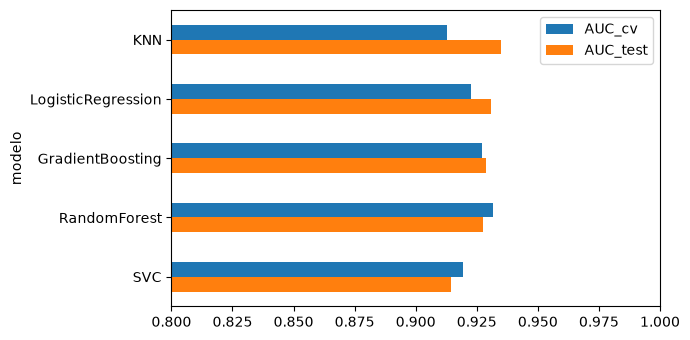

In [6]:
plt.figure(figsize=(7, 3.5))
ranking.set_index("modelo")[["AUC_cv", "AUC_test"]].plot.barh(ax=plt.gca()); plt.xlim(.8, 1)
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()